# Lux systematics on the Willett all-missions RGB sample

Loads the per-star results parquet written at the bottom of
`train-rgb-wilett-all-missions.ipynb` (reference labels and errors, Lux predictions with
formal uncertainties for both splits, per-star spectrum-fit chi-squared, and metadata) and
hunts for **systematics**: structure in the prediction residuals (`pred - reference`)
beyond random scatter. No spectra, jax, or trained model needed -- re-run the training
notebook first if the parquet is stale.

What is checked, and why:

1. **Train vs test scatter** -- a large gap means the latents memorised the training stars.
2. **Residual vs reference label** -- a negative slope is regression to the mean
   (the model under-uses the spectral signal and shrinks toward the sample average).
3. **Cross-label residual correlations** -- residuals of one label trending with *another*
   reference label reveal leakage (e.g. age errors tracking [Fe/H]).
4. **Mission slices (Kepler / K2 / TESS)** -- different targeting, SNR, and age pipelines
   per mission can imprint mission-dependent biases.
5. **Selection channel (seismic vs classified)** -- classifier-selected stars include some
   red-clump contamination; if their residuals differ from the seismic stars', the
   contamination is biasing the model.
6. **SNR trends** -- bias drifting with SNR means the noise model is mis-specified.
7. **Age-specific slices** -- where the age information actually lives ([C/N], [Fe/H],
   the Teff-logg plane), plus the age regression-to-mean check in linear Gyr.
8. **Uncertainty calibration** -- residuals over the total error budget
   (`pred_err` + reference error) should have unit scatter if the formal
   prediction uncertainties can be trusted.
9. **Spectrum-fit chi-squared** -- stars the model cannot represent (high `spec_rchi2`)
   should be flaggable before their labels are used; check whether the chi-squared works
   as a quality cut.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

# results parquet written by train-rgb-wilett-all-missions.ipynb (same dir)
for cand in ['lux-results-rgb-wilett-all-missions.parquet',
             '/scratch/mk27/mj8805/Lux/notebooks/lux-results-rgb-wilett-all-missions.parquet']:
    if os.path.exists(cand):
        results = pd.read_parquet(cand)
        print('loaded', cand)
        break
else:
    raise FileNotFoundError('run train-rgb-wilett-all-missions.ipynb first -- '
                            'its last cell writes the results parquet')

# label list from the pred_* columns (parquet preserves column order);
# pred_err_* are the formal prediction uncertainties, not extra labels
LABEL_NAMES = [c[len('pred_'):] for c in results.columns
               if c.startswith('pred_') and not c.startswith('pred_err_')]
for name in LABEL_NAMES:
    results[f'resid_{name}'] = results[f'pred_{name}'] - results[name]

# per-star diagnostics added later to the training notebook: formal
# prediction uncertainties and the spectrum-fit chi2. Older parquets lack
# them, so sections 8-9 degrade to a pointer instead of crashing.
HAS_PRED_ERR = all(f'pred_err_{n}' in results.columns for n in LABEL_NAMES)
HAS_SPEC_CHI2 = 'spec_rchi2' in results.columns

SNR_COL = next((c for c in ('snr', 'snr_x') if c in results.columns), None)
test = results[results['split'] == 'test'].reset_index(drop=True)
train = results[results['split'] == 'train'].reset_index(drop=True)
print(f'{len(test)} test / {len(train)} train stars; labels: {LABEL_NAMES}')
print(f'prediction uncertainties: {HAS_PRED_ERR}  |  spectrum chi2: {HAS_SPEC_CHI2}')
print(test['source'].value_counts().to_string())


def robust_bias_scatter(d):
    # (median, 1.4826*MAD) over finite values -- the robust bias/scatter
    # convention used throughout the training notebooks
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan, np.nan
    b = np.median(d)
    return b, 1.4826 * np.median(np.abs(d - b))


def binned_median(x, y, nbins=12, min_per_bin=10):
    # Running median of y in equal-count bins of x.
    # Returns (bin centers, median, robust sigma, n) per kept bin.
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    edges = np.quantile(x, np.linspace(0., 1., nbins + 1))
    idx = np.clip(np.searchsorted(edges, x, side='right') - 1, 0, nbins - 1)
    out = []
    for b in range(nbins):
        yb, xb = y[idx == b], x[idx == b]
        if len(yb) < min_per_bin:
            continue
        m = np.median(yb)
        out.append((np.median(xb), m, 1.4826 * np.median(np.abs(yb - m)), len(yb)))
    c, m, s, n = (np.array(v) for v in zip(*out))
    return c, m, s, n

loaded lux-results-rgb-wilett-all-missions.parquet
1521 test / 6080 train stars; labels: ['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'c_n', 'log_age_L']
prediction uncertainties: True  |  spectrum chi2: True
source
K2        747
Kepler    703
TESS       71


## 1. Train vs test: is the model memorising?

The latents (`zetas`) are fit per training star, so Lux can overfit in a way the Cannon's
per-pixel polynomials cannot. Train residuals much tighter than test residuals = the model
is memorising spectra rather than learning the label mapping.

In [2]:
rows = []
for name in LABEL_NAMES:
    b_tr, s_tr = robust_bias_scatter(train[f'resid_{name}'])
    b_te, s_te = robust_bias_scatter(test[f'resid_{name}'])
    rows.append({'label': name, 'train bias': b_tr, 'train scatter': s_tr,
                 'test bias': b_te, 'test scatter': s_te,
                 'test/train scatter': s_te / s_tr if s_tr > 0 else np.nan})
overfit = pd.DataFrame(rows).set_index('label')
with pd.option_context('display.float_format', '{:.4g}'.format):
    print(overfit.to_string())
print('\ntest/train scatter ~ 1 means no memorisation; >> 1 means the latents '
      'overfit the training spectra')

           train bias  train scatter  test bias  test scatter  test/train scatter
label                                                                            
raw_teff        2.029          29.44      2.382         29.63               1.006
raw_logg     0.001106        0.05367 -0.0005974       0.05787               1.078
raw_fe_h    0.0004591         0.0217 -7.561e-05       0.02171               1.001
mg_fe      -0.0003423        0.01723  -0.000708       0.01823               1.058
c_n        -0.0008266        0.05538  -0.004903       0.05536              0.9996
log_age_L    0.006825          0.148   0.008969        0.1555                1.05

test/train scatter ~ 1 means no memorisation; >> 1 means the latents overfit the training spectra


## 2. Residual vs reference label: regression to the mean

For each label, the test residual against the reference value, with an equal-count binned
median and a straight-line fit. A slope of 0 is unbiased; a slope of -1 means predictions
carry no information (pure shrinkage to the sample mean). Some negative slope is expected
from noise in the reference labels themselves (regression dilution), so judge age against
the well-measured labels, not against zero.

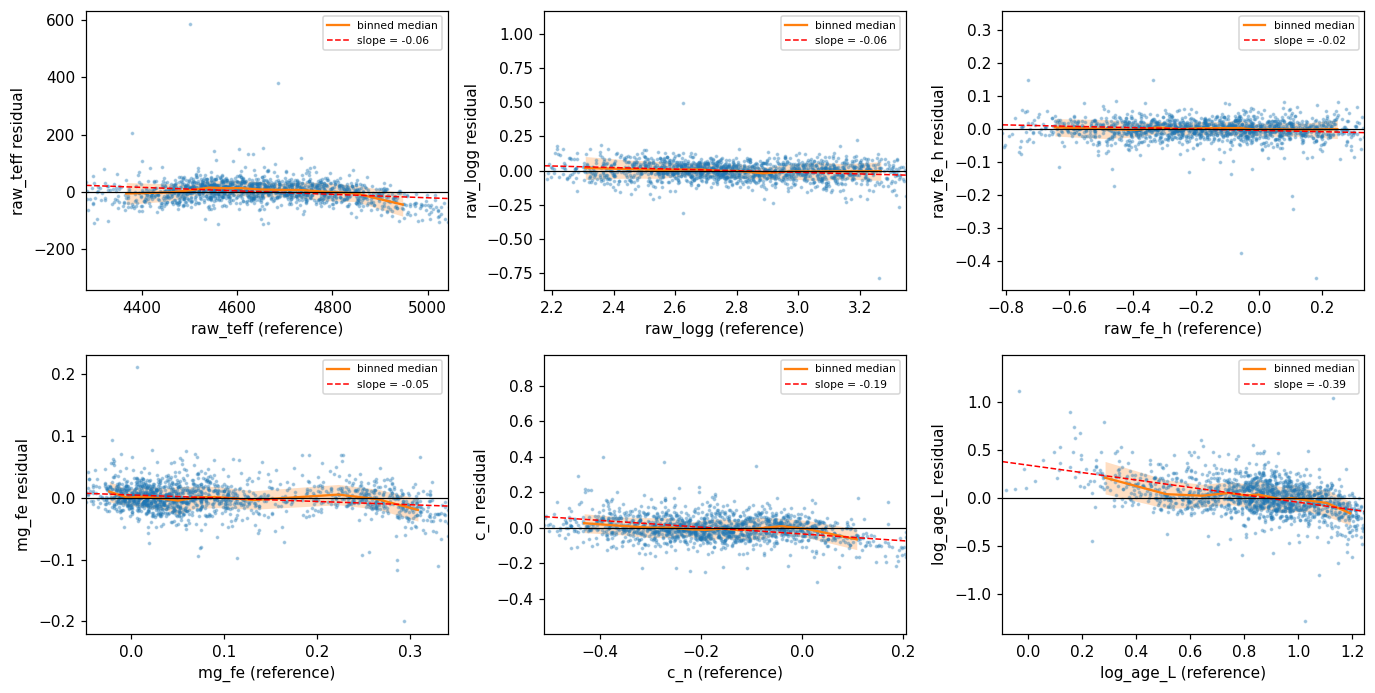

residual-vs-truth slopes (0 = unbiased, -1 = pure shrinkage to the mean):
     raw_teff: -0.061
     raw_logg: -0.058
     raw_fe_h: -0.021
        mg_fe: -0.053
          c_n: -0.191
    log_age_L: -0.386


In [3]:
n_cols = 3
n_rows = int(np.ceil(len(LABEL_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).ravel()
slopes = {}
for m, name in enumerate(LABEL_NAMES):
    ax = axes[m]
    x = test[name].to_numpy(dtype=float)
    r = test[f'resid_{name}'].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(r)
    slope, intercept = np.polyfit(x[ok], r[ok], 1)
    slopes[name] = slope
    ax.plot(x[ok], r[ok], '.', ms=3, alpha=0.3)
    c, med, sig, _ = binned_median(x, r)
    ax.fill_between(c, med - sig, med + sig, alpha=0.25, color='C1', lw=0)
    ax.plot(c, med, '-', color='C1', lw=1.5, label='binned median')
    xx = np.array([np.percentile(x[ok], 1), np.percentile(x[ok], 99)])
    ax.plot(xx, slope * xx + intercept, 'r--', lw=1,
            label=f'slope = {slope:+.2f}')
    ax.axhline(0., color='k', lw=0.8)
    ax.set_xlim(xx)
    ax.set_xlabel(f'{name} (reference)')
    ax.set_ylabel(f'{name} residual')
    ax.legend(fontsize=7)
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

print('residual-vs-truth slopes (0 = unbiased, -1 = pure shrinkage to the mean):')
for name, s in slopes.items():
    print(f'  {name:>11}: {s:+.3f}')

## 3. Cross-label systematics

Spearman correlation between each label's residual (rows) and every *reference* label
(columns). The diagonal repeats the regression-to-the-mean effect above; off-diagonal
structure is leakage -- e.g. an age-residual column trending with c_n would mean the model
confuses the [C/N] abundance with the age signal it carries.

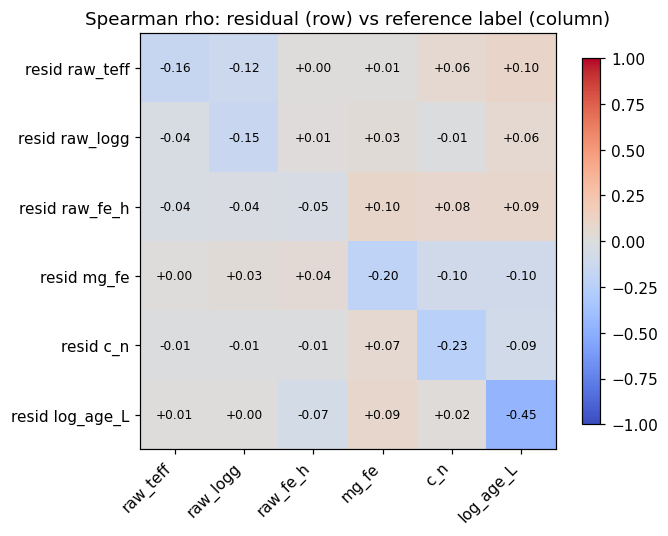

In [4]:
from scipy.stats import spearmanr

rho = np.full((len(LABEL_NAMES), len(LABEL_NAMES)), np.nan)
for i, rname in enumerate(LABEL_NAMES):
    r = test[f'resid_{rname}'].to_numpy(dtype=float)
    for j, tname in enumerate(LABEL_NAMES):
        t = test[tname].to_numpy(dtype=float)
        ok = np.isfinite(r) & np.isfinite(t)
        rho[i, j] = spearmanr(r[ok], t[ok]).statistic

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(rho, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(LABEL_NAMES)), LABEL_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(LABEL_NAMES)), [f'resid {n}' for n in LABEL_NAMES])
for (i, j), v in np.ndenumerate(rho):
    ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=8,
            color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Spearman rho: residual (row) vs reference label (column)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Mission slices: Kepler vs K2 vs TESS

The three missions differ in targeting, typical SNR, and how their seismic ages were
derived, so a mission-dependent bias is the most likely bulk systematic in this sample.
Error bars are the robust error on the median (1.25 * sigma / sqrt(n)); non-overlapping
bars flag a real offset.

          n  raw_teff bias  raw_teff scatter  raw_logg bias  raw_logg scatter  raw_fe_h bias  raw_fe_h scatter  mg_fe bias  mg_fe scatter  c_n bias  c_n scatter  log_age_L bias  log_age_L scatter
source                                                                                                                                                                                             
K2      747          1.708             32.68       0.005309           0.06022     -0.0003628           0.02267  -0.0009668        0.01997 -0.002008       0.0547        0.004971             0.1738
Kepler  703          2.164             27.75       -0.00517           0.05502       0.001418           0.02119  -0.0005244          0.017   -0.0077      0.05409          0.0151             0.1358
TESS     71          9.267              21.9        0.01024           0.06942      -0.004305           0.02016    0.001304        0.01567   0.01335      0.05393        -0.02439             0.1388


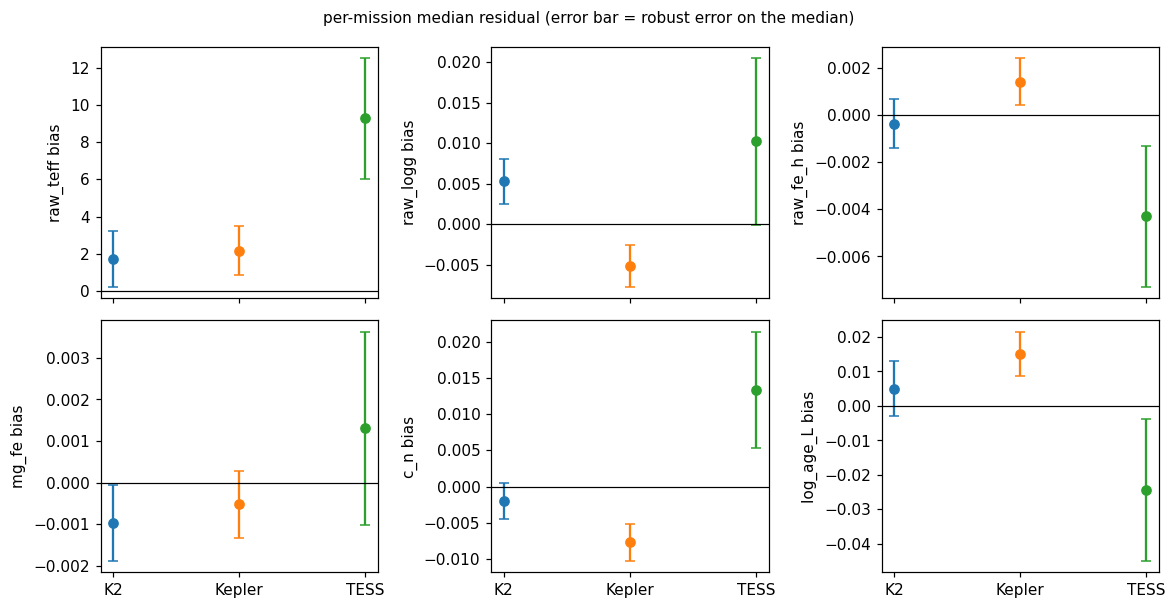

In [5]:
def group_table(frame, by):
    rows = []
    for key, g in frame.groupby(by, observed=True):
        row = {by: key, 'n': len(g)}
        for name in LABEL_NAMES:
            b, s = robust_bias_scatter(g[f'resid_{name}'])
            row[f'{name} bias'] = b
            row[f'{name} scatter'] = s
        rows.append(row)
    return pd.DataFrame(rows).set_index(by)

by_source = group_table(test, 'source')
with pd.option_context('display.float_format', '{:.4g}'.format,
                       'display.width', 200):
    print(by_source.to_string())

n_cols = 3
n_rows = int(np.ceil(len(LABEL_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 2.8 * n_rows),
                         sharex=True)
axes = np.atleast_1d(axes).ravel()
sources = list(by_source.index)
for m, name in enumerate(LABEL_NAMES):
    ax = axes[m]
    for k, src in enumerate(sources):
        g = test[test['source'] == src][f'resid_{name}']
        b, s = robust_bias_scatter(g)
        n = np.isfinite(g).sum()
        ax.errorbar(k, b, yerr=1.25 * s / np.sqrt(max(n, 1)), fmt='o',
                    color=f'C{k}', capsize=3)
    ax.axhline(0., color='k', lw=0.8)
    ax.set_xticks(range(len(sources)), sources)
    ax.set_ylabel(f'{name} bias')
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
plt.suptitle('per-mission median residual (error bar = robust error on the median)',
             fontsize=10)
plt.tight_layout()
plt.show()

## 5. Selection channel: seismic vs classified

The classifier-selected stars (all of K2/TESS plus ambiguous Kepler rows) carry some
red-clump contamination at the p > 0.9 threshold. RC stars have systematically different
[C/N] at fixed age, so contamination should show up as (a) an offset between the two
channels and (b) residuals trending with the classifier probability -- the least confident
accepts should be the most contaminated.

                    n  raw_teff bias  raw_teff scatter  raw_logg bias  raw_logg scatter  raw_fe_h bias  raw_fe_h scatter  mg_fe bias  mg_fe scatter   c_n bias  c_n scatter  log_age_L bias  log_age_L scatter
evo_state_source                                                                                                                                                                                              
classified        828          2.353             31.95       0.005313            0.0618     -0.0006889           0.02235  -0.0009243        0.01949 -0.0005668       0.0542        0.002966             0.1726
seismic           693          2.382              27.5      -0.005164           0.05498       0.001374           0.02096  -0.0004732        0.01707    -0.0077      0.05409         0.01438             0.1346


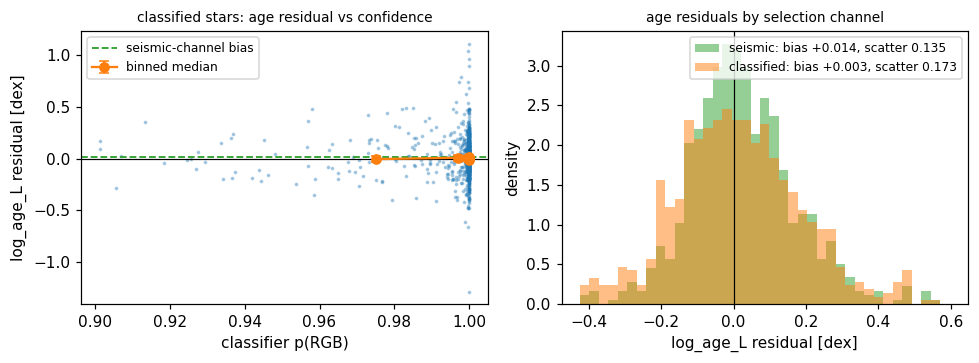

In [6]:
by_channel = group_table(test, 'evo_state_source')
with pd.option_context('display.float_format', '{:.4g}'.format,
                       'display.width', 200):
    print(by_channel.to_string())

# age residual vs classifier probability, classified stars only
cls = test[test['evo_state_source'] == 'classified']
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

ax = axes[0]
x = cls['rgb_proba'].to_numpy(dtype=float)
r = cls['resid_log_age_L'].to_numpy(dtype=float)
ax.plot(x, r, '.', ms=3, alpha=0.3)
c, med, sig, n = binned_median(x, r, nbins=8)
ax.errorbar(c, med, yerr=1.25 * sig / np.sqrt(n), fmt='o-', color='C1', lw=1.5,
            capsize=3, label='binned median')
b_seis, _ = robust_bias_scatter(test.loc[test['evo_state_source'] == 'seismic',
                                         'resid_log_age_L'])
ax.axhline(b_seis, color='C2', ls='--', lw=1.2, label='seismic-channel bias')
ax.axhline(0., color='k', lw=0.8)
ax.set_xlabel('classifier p(RGB)')
ax.set_ylabel('log_age_L residual [dex]')
ax.set_title('classified stars: age residual vs confidence', fontsize=9)
ax.legend(fontsize=8)

# residual distributions of the two channels
ax = axes[1]
bins = np.linspace(*np.nanpercentile(test['resid_log_age_L'], [1, 99]), 40)
for channel, color in (('seismic', 'C2'), ('classified', 'C1')):
    d = test.loc[test['evo_state_source'] == channel, 'resid_log_age_L']
    b, s = robust_bias_scatter(d)
    ax.hist(d, bins=bins, density=True, alpha=0.5, color=color,
            label=f'{channel}: bias {b:+.3f}, scatter {s:.3f}')
ax.axvline(0., color='k', lw=0.8)
ax.set_xlabel('log_age_L residual [dex]')
ax.set_ylabel('density')
ax.set_title('age residuals by selection channel', fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. SNR trends

Bias drifting with SNR means the flux noise model is mis-specified (e.g. the per-pixel
scatters absorbing real signal at low SNR); scatter should shrink with SNR and then floor
at the label-noise limit.

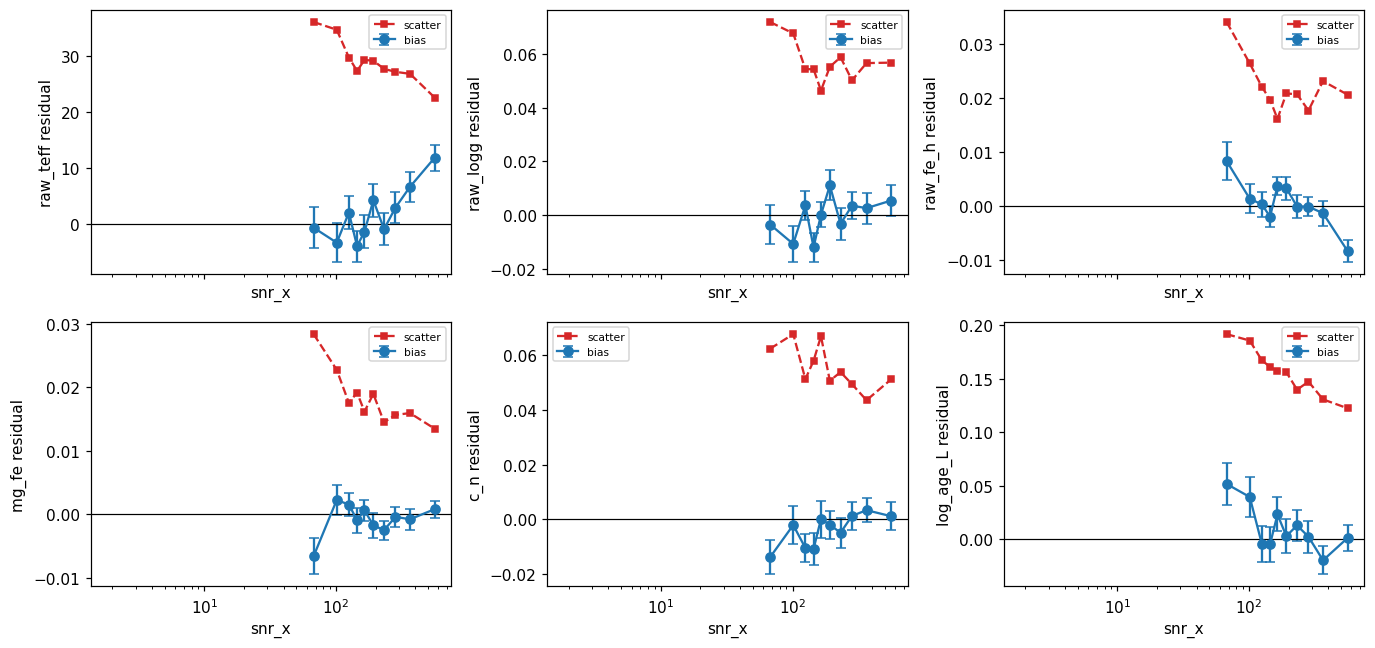

In [7]:
if SNR_COL is None:
    print('no SNR column in the results parquet -- re-run the training notebook '
          'with snr in META_COLS to enable this check')
else:
    snr = test[SNR_COL].to_numpy(dtype=float)
    n_cols = 3
    n_rows = int(np.ceil(len(LABEL_NAMES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.0 * n_rows),
                             sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for m, name in enumerate(LABEL_NAMES):
        ax = axes[m]
        r = test[f'resid_{name}'].to_numpy(dtype=float)
        c, med, sig, n = binned_median(snr, r, nbins=10)
        ax.errorbar(c, med, yerr=1.25 * sig / np.sqrt(n), fmt='o-', color='C0',
                    capsize=3, label='bias')
        ax.plot(c, sig, 's--', color='C3', ms=4, label='scatter')
        ax.axhline(0., color='k', lw=0.8)
        ax.set_xscale('log')
        ax.set_xlabel(SNR_COL)
        ax.set_ylabel(f'{name} residual')
        ax.legend(fontsize=7)
    for ax in axes[len(LABEL_NAMES):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## 7. Age-specific systematics

Age is the label that matters and the one with the least direct spectral signal (it rides
on the [C/N] clock), so slice its residual against the quantities most likely to bias it,
and check the linear-Gyr regression to the mean.

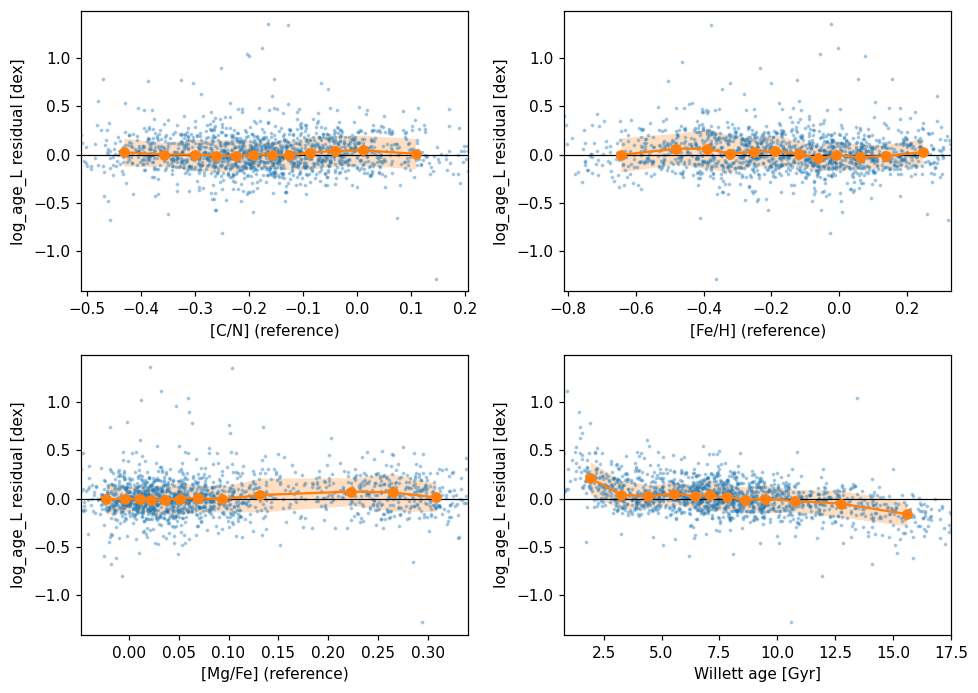

In [8]:
age_true = 10**test['log_age_L'].to_numpy(dtype=float)
age_pred = 10**test['pred_log_age_L'].to_numpy(dtype=float)
r_log = test['resid_log_age_L'].to_numpy(dtype=float)

panels = [(test['c_n'], '[C/N] (reference)'),
          (test['raw_fe_h'], '[Fe/H] (reference)'),
          (test['mg_fe'], '[Mg/Fe] (reference)'),
          (age_true, 'Willett age [Gyr]')]
fig, axes = plt.subplots(2, 2, figsize=(9, 6.4))
for ax, (x, xlabel) in zip(axes.ravel(), panels):
    x = np.asarray(x, dtype=float)
    ax.plot(x, r_log, '.', ms=3, alpha=0.3)
    c, med, sig, n = binned_median(x, r_log)
    ax.fill_between(c, med - sig, med + sig, alpha=0.25, color='C1', lw=0)
    ax.errorbar(c, med, yerr=1.25 * sig / np.sqrt(n), fmt='o-', color='C1',
                lw=1.5, capsize=3)
    ax.axhline(0., color='k', lw=0.8)
    ok = np.isfinite(x)
    ax.set_xlim(np.percentile(x[ok], 1), np.percentile(x[ok], 99))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('log_age_L residual [dex]')
plt.tight_layout()
plt.show()

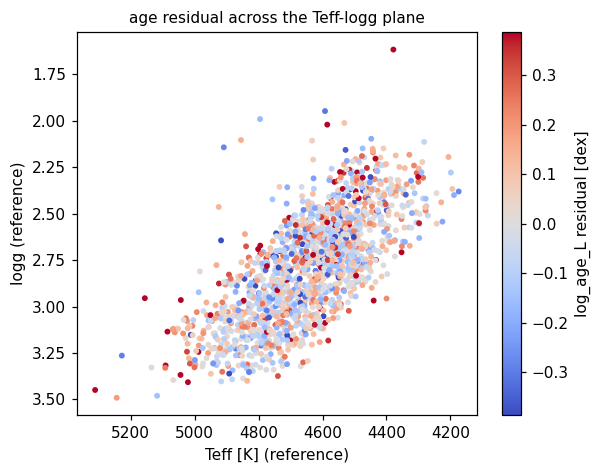

In [9]:
# Where in the Teff-logg plane do the age errors live? Systematics pooling
# in one corner (e.g. the clump box, upper RGB, or the low-logg TESS stars)
# point at contamination or training-set coverage rather than a global bias.
r_clip = np.nanpercentile(np.abs(r_log), 95)

fig, ax = plt.subplots(figsize=(5.6, 4.4))
sc = ax.scatter(test['raw_teff'], test['raw_logg'], c=r_log, s=8,
                cmap='coolwarm', vmin=-r_clip, vmax=r_clip)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('Teff [K] (reference)')
ax.set_ylabel('logg (reference)')
ax.set_title('age residual across the Teff-logg plane', fontsize=10)
fig.colorbar(sc, ax=ax, label='log_age_L residual [dex]')
plt.tight_layout()
plt.show()

## 8. Are the formal prediction uncertainties calibrated?

The parquet carries `pred_err_*`: the formal label uncertainty propagated from each
star's flux errors through the exact latent solve. The residual `pred - reference` mixes
that with the reference-label noise, so a calibrated model has unit robust scatter of
`resid / sqrt(pred_err^2 + ref_err^2)`.

Two versions of the denominator:

- **z(raw)** uses the catalogue reference errors as-is. ASPCAP quotes internal precisions
  (median ~0.001 dex in [Fe/H]), so z(raw) >> 1 mostly indicts the catalogue, not the model.
- **z(floored)** first raises each reference error to the same literature floors the
  training weights use -- the fair test. Scatter >> 1 *there* is real model error; the
  `sys floor` column quantifies the excess, i.e. what to add in quadrature to `pred_err`
  when quoting that label per star.

           med pred err  med ref err  ref floor  resid scatter  z(raw)  z(floored)    z bias  sys floor
label                                                                                                  
raw_teff          9.681        3.869         30          29.63    2.67      0.9223   0.07533          0
raw_logg        0.01812        0.008       0.05        0.05787   2.766       1.056  -0.01128     0.0228
raw_fe_h       0.006576        0.001       0.03        0.02171   3.117      0.7014 -0.002478          0
mg_fe          0.005524     0.003317       0.03        0.01823   2.668      0.5937  -0.02009          0
c_n             0.01227     0.005099       0.07        0.05536   3.808      0.7719  -0.06952          0
log_age_L       0.03282      0.07613       0.05         0.1555   1.631       1.621    0.0997     0.1315

z(floored) ~ 1: pred_err plus the literature reference floor covers the residuals; >> 1: real
model error -- quote sqrt(pred_err^2 + sys floor^2) per star for that lab

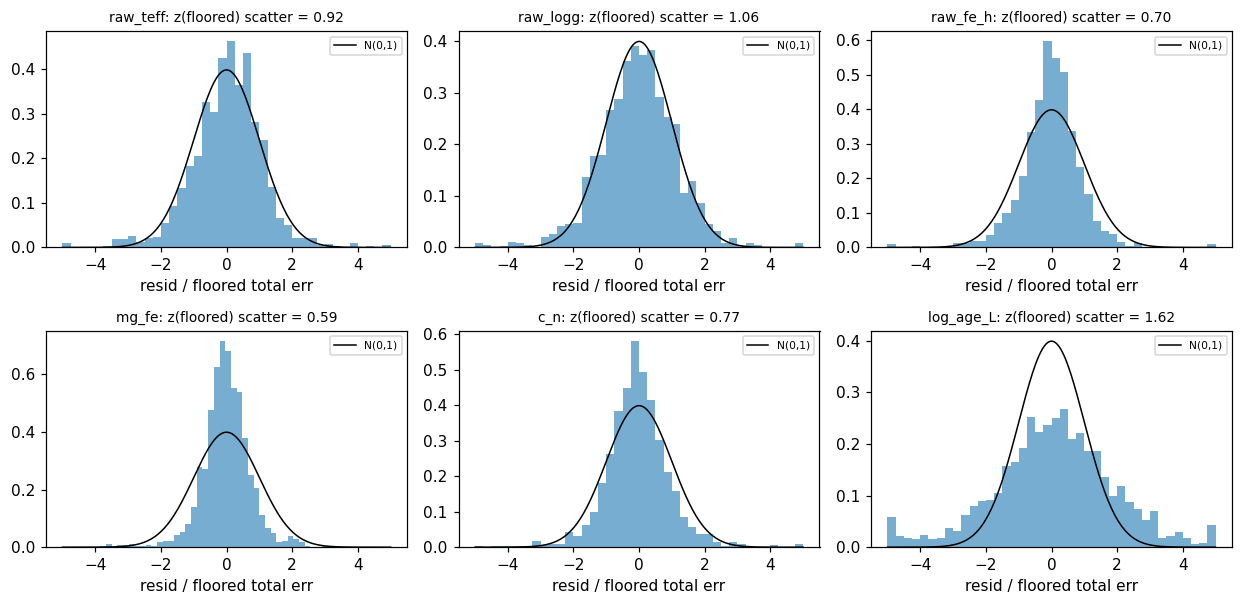

In [10]:
if not HAS_PRED_ERR:
    print('no pred_err_* columns in the parquet -- re-run '
          'train-rgb-wilett-all-missions.ipynb to add them')
else:
    # reference-label error columns, matching ERR_COLS in the training notebook
    REF_ERR_COLS = {'raw_teff': 'raw_e_teff', 'raw_logg': 'raw_e_logg',
                    'raw_fe_h': 'raw_e_fe_h', 'mg_fe': 'e_mg_fe',
                    'c_n': 'c_n_err', 'log_age_L': 'e_log_age_L'}
    # literature accuracy floors, matching err_floor in the training notebook
    ERR_FLOOR = {'raw_teff': 30., 'raw_logg': 0.05, 'raw_fe_h': 0.03,
                 'mg_fe': 0.03, 'c_n': 0.07, 'log_age_L': 0.05}

    rows, z_floored = [], {}
    for name in LABEL_NAMES:
        r = test[f'resid_{name}'].to_numpy(dtype=float)
        pe = test[f'pred_err_{name}'].to_numpy(dtype=float)
        ec = REF_ERR_COLS.get(name)
        re_raw = (test[ec].to_numpy(dtype=float) if ec in test.columns
                  else np.full_like(r, np.nan))
        re_raw = np.where((re_raw > 0) & (re_raw < 9000), re_raw, np.nan)
        re_fl = np.maximum(re_raw, ERR_FLOOR.get(name, 0.))  # NaN stays NaN
        z_raw = r / np.sqrt(pe**2 + re_raw**2)
        z_fl = r / np.sqrt(pe**2 + re_fl**2)
        z_floored[name] = z_fl
        _, s_r = robust_bias_scatter(r)
        _, s_zraw = robust_bias_scatter(z_raw)
        b_zfl, s_zfl = robust_bias_scatter(z_fl)
        # residual variance the pred_err + floored-reference budget cannot
        # explain: the systematic to add in quadrature when quoting the label
        sys2 = s_r**2 - np.nanmedian(pe)**2 - np.nanmedian(re_fl)**2
        rows.append({'label': name, 'med pred err': np.nanmedian(pe),
                     'med ref err': np.nanmedian(re_raw),
                     'ref floor': ERR_FLOOR.get(name, 0.),
                     'resid scatter': s_r, 'z(raw)': s_zraw,
                     'z(floored)': s_zfl, 'z bias': b_zfl,
                     'sys floor': np.sqrt(max(sys2, 0.))})
    calib = pd.DataFrame(rows).set_index('label')
    with pd.option_context('display.float_format', '{:.4g}'.format,
                           'display.width', 200):
        print(calib.to_string())
    print('\nz(floored) ~ 1: pred_err plus the literature reference floor '
          'covers the residuals; >> 1: real\nmodel error -- quote '
          'sqrt(pred_err^2 + sys floor^2) per star for that label. z(raw) '
          'trusts the\ncatalogue errors as-is and mostly measures how '
          'optimistic ASPCAP internal precisions are.')

    n_cols = 3
    n_rows_f = int(np.ceil(len(LABEL_NAMES) / n_cols))
    fig, axes = plt.subplots(n_rows_f, n_cols,
                             figsize=(3.8 * n_cols, 2.8 * n_rows_f))
    axes = np.atleast_1d(axes).ravel()
    zz = np.linspace(-5, 5, 200)
    for m, name in enumerate(LABEL_NAMES):
        ax = axes[m]
        z = z_floored[name]
        z = z[np.isfinite(z)]
        ax.hist(np.clip(z, -5, 5), bins=40, density=True, alpha=0.6)
        ax.plot(zz, np.exp(-zz**2 / 2) / np.sqrt(2 * np.pi), 'k-', lw=1,
                label='N(0,1)')
        _, s = robust_bias_scatter(z)
        ax.set_title(f'{name}: z(floored) scatter = {s:.2f}', fontsize=9)
        ax.set_xlabel('resid / floored total err')
        ax.legend(fontsize=7)
    for ax in axes[len(LABEL_NAMES):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## 9. Spectrum-fit chi-squared as a quality flag

`spec_rchi2` is the chi-squared of each star's synthesised spectrum against the observed
one (under the inference weights, including the fitted per-pixel scatters) per degree of
freedom. A value near 1 means the noise model describes the residuals; the high tail
flags stars the model cannot represent -- bad continuum normalization, binaries, emission,
or evolutionary-state contamination. If label residuals grow with `spec_rchi2`, it works
as a per-star quality cut for the science sample.

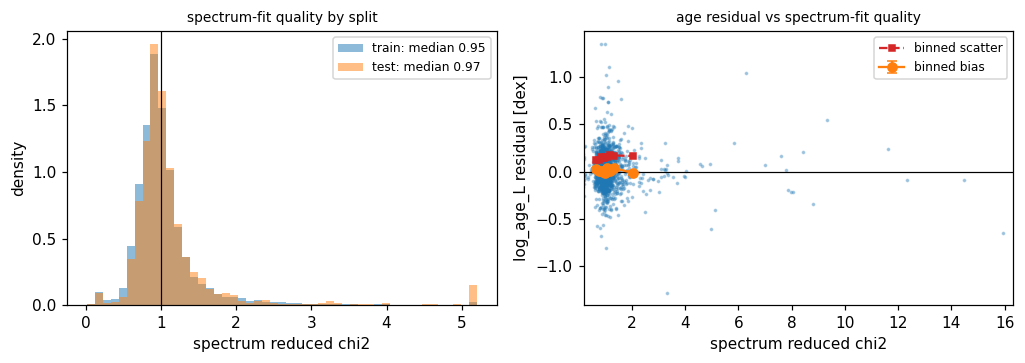

  keep   rchi2 <=    raw_teff    raw_logg    raw_fe_h       mg_fe         c_n   log_age_L
  100%        130        29.6      0.0579      0.0217      0.0182      0.0554       0.155
   99%       8.03        29.5      0.0574      0.0217      0.0182      0.0552       0.155
   95%       2.02        29.3       0.056      0.0214      0.0177      0.0547       0.155
   90%       1.55        28.7      0.0545       0.021      0.0173      0.0542       0.154


In [11]:
if not HAS_SPEC_CHI2:
    print('no spec_* columns in the parquet -- re-run '
          'train-rgb-wilett-all-missions.ipynb to add them')
else:
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

    # distribution per split: train stars help shape the betas, so a test
    # tail extending beyond the train one is genuine out-of-model structure
    ax = axes[0]
    hi = np.nanpercentile(results['spec_rchi2'], 99.5)
    bins = np.linspace(np.nanmin(results['spec_rchi2']), hi, 50)
    for frame, label, color in ((train, 'train', 'C0'), (test, 'test', 'C1')):
        ax.hist(np.clip(frame['spec_rchi2'], None, hi), bins=bins, density=True,
                alpha=0.5, color=color,
                label=f'{label}: median {np.nanmedian(frame["spec_rchi2"]):.2f}')
    ax.axvline(1., color='k', lw=0.8)
    ax.set_xlabel('spectrum reduced chi2')
    ax.set_ylabel('density')
    ax.set_title('spectrum-fit quality by split', fontsize=9)
    ax.legend(fontsize=8)

    # does a bad spectral fit predict a bad age?
    ax = axes[1]
    x = test['spec_rchi2'].to_numpy(dtype=float)
    r = test['resid_log_age_L'].to_numpy(dtype=float)
    ax.plot(x, r, '.', ms=3, alpha=0.3)
    c, med, sig, n = binned_median(x, r, nbins=10)
    ax.errorbar(c, med, yerr=1.25 * sig / np.sqrt(n), fmt='o-', color='C1',
                lw=1.5, capsize=3, label='binned bias')
    ax.plot(c, sig, 's--', color='C3', ms=4, label='binned scatter')
    ax.axhline(0., color='k', lw=0.8)
    ax.set_xlim(np.nanpercentile(x, [0.5, 99.5]))
    ax.set_xlabel('spectrum reduced chi2')
    ax.set_ylabel('log_age_L residual [dex]')
    ax.set_title('age residual vs spectrum-fit quality', fontsize=9)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # what a chi2 quality cut buys: residual scatter after keeping the
    # best-fitting fraction of the test set
    print(f'{"keep":>6}  {"rchi2 <=":>9}  ' +
          '  '.join(f'{n:>10}' for n in LABEL_NAMES))
    for frac in (1.0, 0.99, 0.95, 0.90):
        cut = np.nanquantile(x, frac)
        keep = x <= cut
        scatters = [robust_bias_scatter(test.loc[keep, f'resid_{n}'])[1]
                    for n in LABEL_NAMES]
        print(f'{frac:>6.0%}  {cut:>9.3g}  ' +
              '  '.join(f'{s:>10.3g}' for s in scatters))

## 10. One-to-one comparisons coloured by spectrum-fit chi-squared

The Lux counterpart of the Cannon one-to-one figure in
`AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb`: held-out test predictions
against the ASPCAP/Willett reference labels, each star coloured by its `spec_rchi2` on a
log scale. If the outliers in any panel light up in yellow, the spectral fit already knew
those stars were bad and the section-9 quality cut will remove them; dark outliers are
labels the model gets wrong while fitting the spectrum well -- true label-space
systematics.

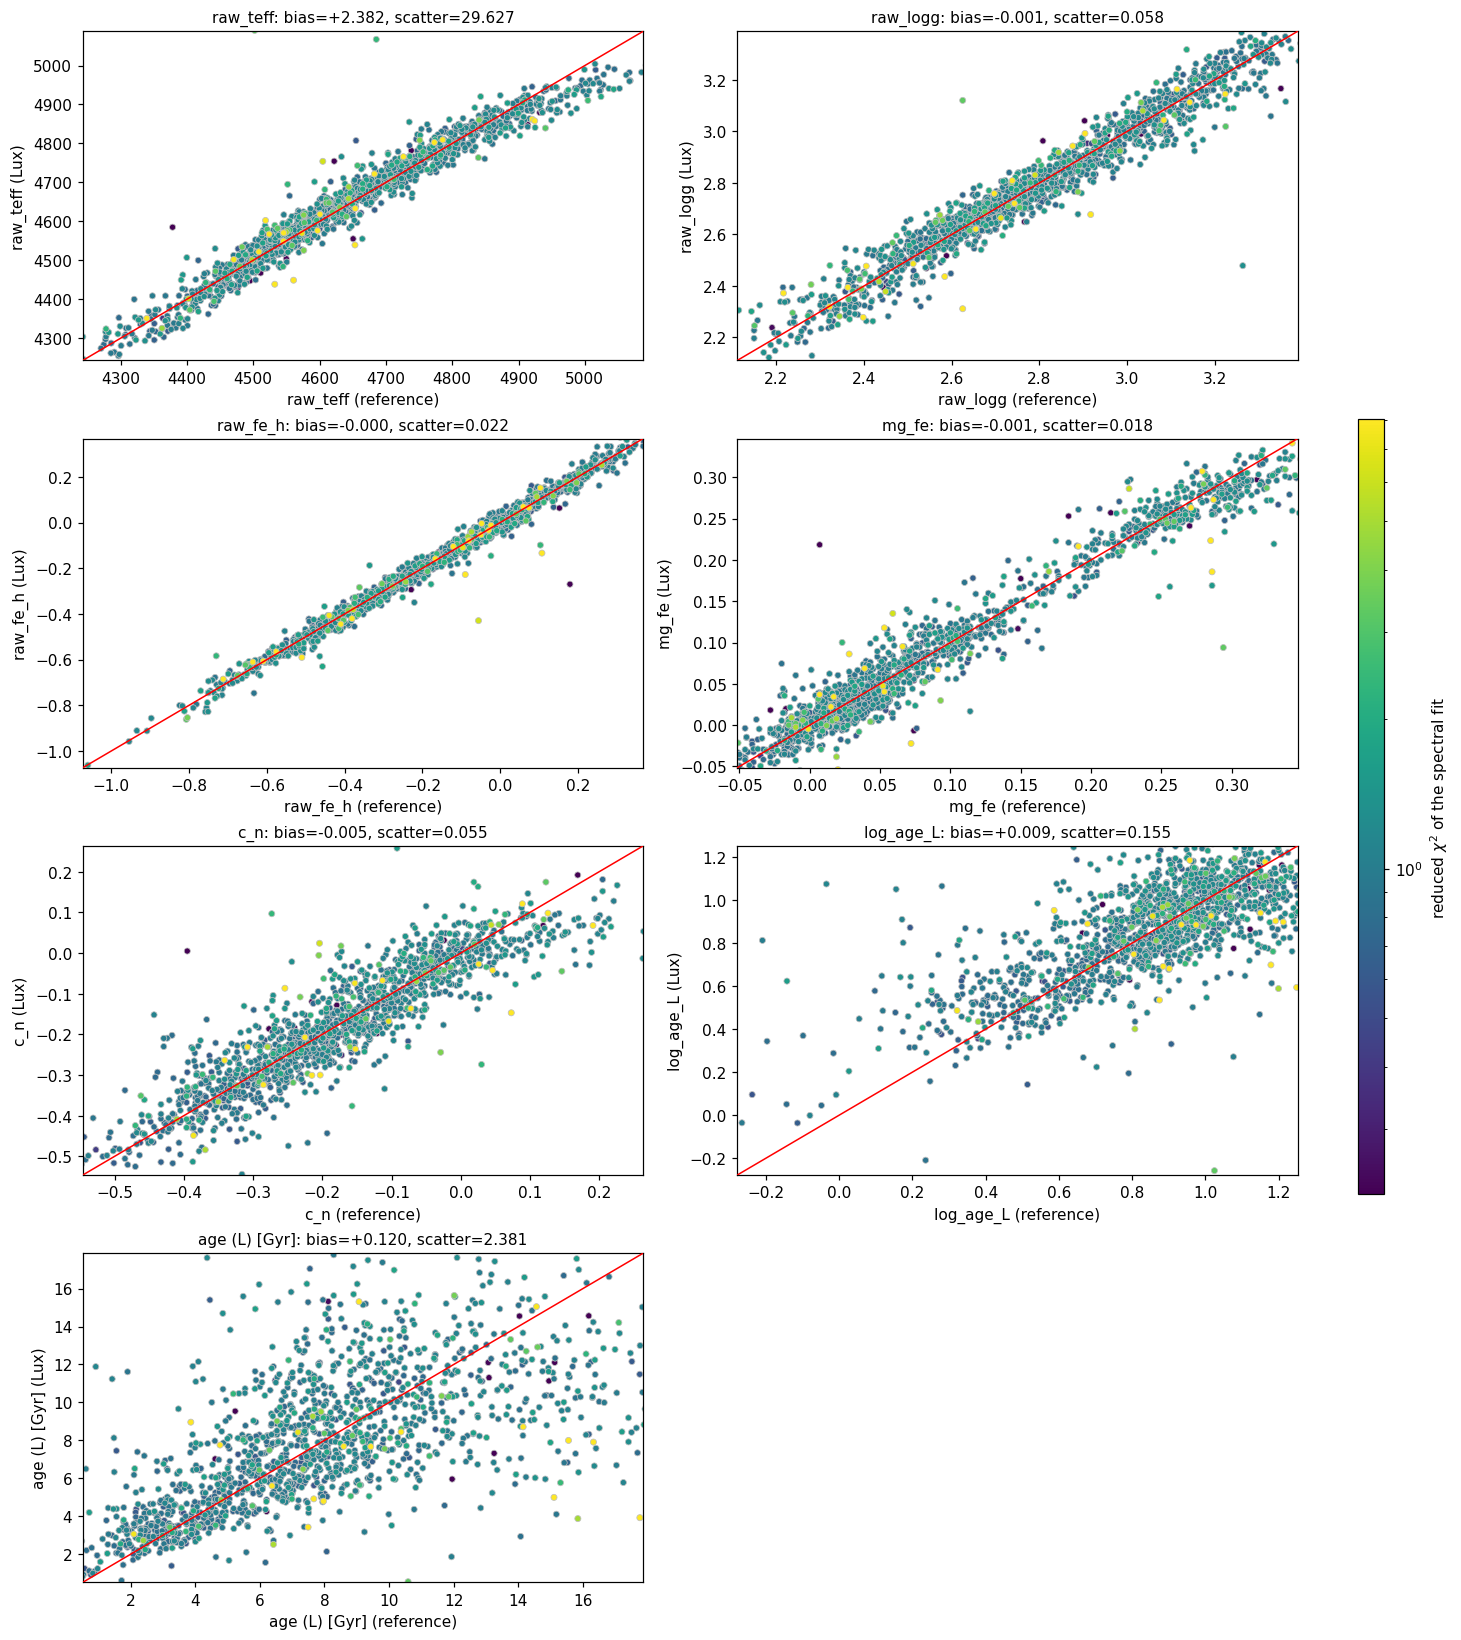

In [19]:
if not HAS_SPEC_CHI2:
    print('no spec_* columns in the parquet -- re-run '
          'train-rgb-wilett-all-missions.ipynb to add them')
else:
    from matplotlib.colors import LogNorm

    chi = test['spec_rchi2'].to_numpy(dtype=float)
    ok_chi = np.isfinite(chi) & (chi > 0)
    # one shared log colour scale across the panels; clip the extreme tails
    # so a handful of terrible fits do not compress the rest of the range
    norm = LogNorm(*np.nanpercentile(chi[ok_chi], [1, 99]))

    # the trained labels, plus the age panel back in linear Gyr
    panels = [(name, test[name].to_numpy(dtype=float),
               test[f'pred_{name}'].to_numpy(dtype=float))
              for name in LABEL_NAMES]
    panels.append(('age (L) [Gyr]',
                   10**test['log_age_L'].to_numpy(dtype=float),
                   10**test['pred_log_age_L'].to_numpy(dtype=float)))

    n_cols = 2
    n_rows_c = int(np.ceil(len(panels) / n_cols))
    fig, axes = plt.subplots(n_rows_c, n_cols,
                             figsize=(6.6 * n_cols, 3.7 * n_rows_c),
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (name, x, y) in zip(axes, panels):
        ok = np.isfinite(x) & np.isfinite(y) & ok_chi
        b, s = robust_bias_scatter(y[ok] - x[ok])
        lims = np.percentile(x[ok], [0.5, 99.5])
        ax.plot(lims, lims, 'r-', lw=1, zorder=3)
        order = np.argsort(chi[ok])           # worst fits drawn on top
        sc = ax.scatter(x[ok][order], y[ok][order], c=chi[ok][order], s=16,
                        cmap='viridis', norm=norm,
                        edgecolors='0.75', linewidths=0.5)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_title(f'{name}: bias={b:+.3f}, scatter={s:.3f}', fontsize=10)
        ax.set_xlabel(f'{name} (reference)')
        ax.set_ylabel(f'{name} (Lux)')
    for ax in axes[len(panels):]:
        ax.set_visible(False)
    fig.colorbar(sc, ax=axes, shrink=0.5, aspect=30,
                 label='reduced $\\chi^2$ of the spectral fit')
    plt.show()

## Reading the results

- **Section 1**: test/train scatter ratios near 1 -- fine; if age is >> 1 while Teff/[Fe/H]
  are ~1, the latents are memorising the weak age signal specifically (raise l2, or lower P).
- **Section 2**: strongly negative age slope with flat Teff/[Fe/H] slopes = the classic
  "ages regress to the sample mean" failure; more latent capacity for the CN features or
  weaker flux regularisation is the lever.
- **Section 3**: an age-residual row correlating with c_n means age and [C/N] are fighting
  over the same pixels (the AnniesLasso notebooks saw exactly this trade-off).
- **Section 4/5**: mission or channel offsets larger than their error bars should be fixed
  in the *sample* (per-mission zero points, stricter classifier threshold), not the model.
- **Section 6**: bias drifting with SNR -- revisit the error floors / per-pixel scatters.
- **Section 8**: judge on z(floored), not z(raw). Near 1: `pred_err` (plus the literature
  floor) is usable per star. Well above 1: quote sqrt(pred_err^2 + sys floor^2) instead;
  the sweep notebook (`sweep-p-l2-rgb-wilett-all-missions.ipynb`) hunts the (P, l2) that
  shrinks that sys floor.
- **Section 9**: if the chi2 cut shrinks the age scatter, adopt it as a sample cut; if the
  scatter is flat in chi2, the bad fits are noise (not systematics) and no cut is needed.

In [13]:
test

,APOGEE_ID,source,evo_state_source,rgb_proba,EvoState,snr_x,numax,raw_teff,raw_logg,raw_fe_h,...,pred_err_log_age_L,spec_chi2,spec_n_pix,spec_rchi2,resid_raw_teff,resid_raw_logg,resid_raw_fe_h,resid_mg_fe,resid_c_n,resid_log_age_L
0,2M19245967+3638183,Kepler,seismic,NaN,1.0,254.708313,41.39,4641.774902,2.562,-0.247,...,0.026199,6634.150235,6934.0,0.974750,2.424474,0.032920,-0.005397,0.008890,0.038336,0.406042
1,2M19270812+3657217,Kepler,seismic,NaN,1.0,75.946632,126.62,4862.188965,3.126,-0.009,...,0.053243,5553.155922,6886.0,0.821716,-29.235401,-0.012174,-0.029807,0.042234,-0.034924,-0.123511
2,2M19265417+3702187,Kepler,seismic,NaN,1.0,594.156311,150.14,4672.125977,3.091,0.202,...,0.021405,6130.527684,6934.0,0.900753,-23.178470,0.037669,-0.045332,0.009064,0.096777,0.078989
3,2M19260495+3707141,Kepler,seismic,NaN,1.0,114.408630,124.25,4934.720215,2.993,-0.404,...,0.040461,6840.962408,6934.0,1.005137,-50.600836,-0.069136,-0.053846,0.042389,0.023752,0.152359
4,2M19240872+3712254,Kepler,seismic,NaN,1.0,105.345306,136.07,4886.515137,3.089,-0.293,...,0.039841,5018.855228,6890.0,0.742215,-16.587252,-0.060451,0.005623,0.019866,0.132913,0.208385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516,2M19200838-2934238,K2,classified,0.992229,NaN,87.817398,18.80,4632.979004,2.107,-1.196,...,0.051264,8667.564359,6889.0,1.281994,132.992368,0.196807,0.063866,-0.083550,0.163978,0.061831
1517,2M13391559-1305383,K2,classified,0.999756,NaN,128.328354,46.51,4554.999023,2.561,-0.522,...,0.040371,10215.016686,6885.0,1.511768,45.686049,0.027782,-0.000206,-0.002176,0.074725,-0.123353
1518,2M05091616+1558333,K2,classified,0.999980,NaN,235.858276,57.43,4702.238770,2.555,-0.745,...,0.027080,6352.914101,6934.0,0.933428,37.908160,0.009451,0.008559,-0.031172,-0.051080,-0.159715
1519,2M03592631+2551204,K2,classified,0.999933,NaN,419.524780,58.83,4437.225098,2.695,0.090,...,0.023589,4806.250285,6899.0,0.709829,1.642550,0.054552,-0.005147,0.001827,0.057627,-0.034655


(array([1.12e+02, 1.11e+03, 1.96e+02, 4.30e+01, 1.10e+01, 1.50e+01,
        6.00e+00, 2.00e+00, 3.00e+00, 1.00e+00]),
 array([  650.10374697,  4543.91972177,  8437.73569657, 12331.55167137,
        16225.36764617, 20119.18362096, 24012.99959576, 27906.81557056,
        31800.63154536, 35694.44752016, 39588.26349496]),
 <BarContainer object of 10 artists>)

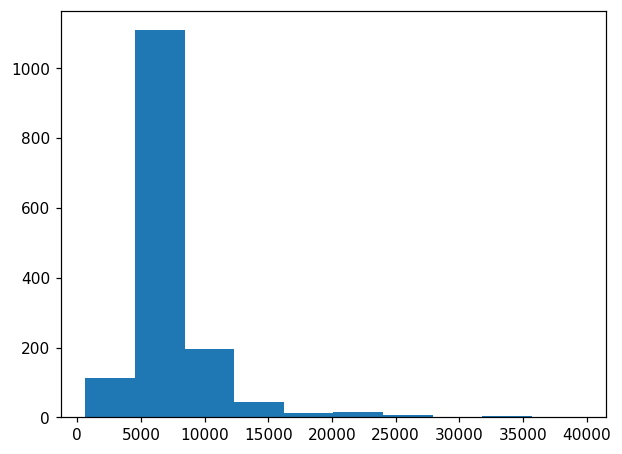

In [14]:
# Keep stars with spec_chi2 less than 2 standard deviations above the mean
good_chi = test['spec_chi2'] < (np.nanmean(test['spec_chi2']) + np.nanstd(test['spec_chi2']))
plt.hist(test[good_chi]['spec_chi2'])

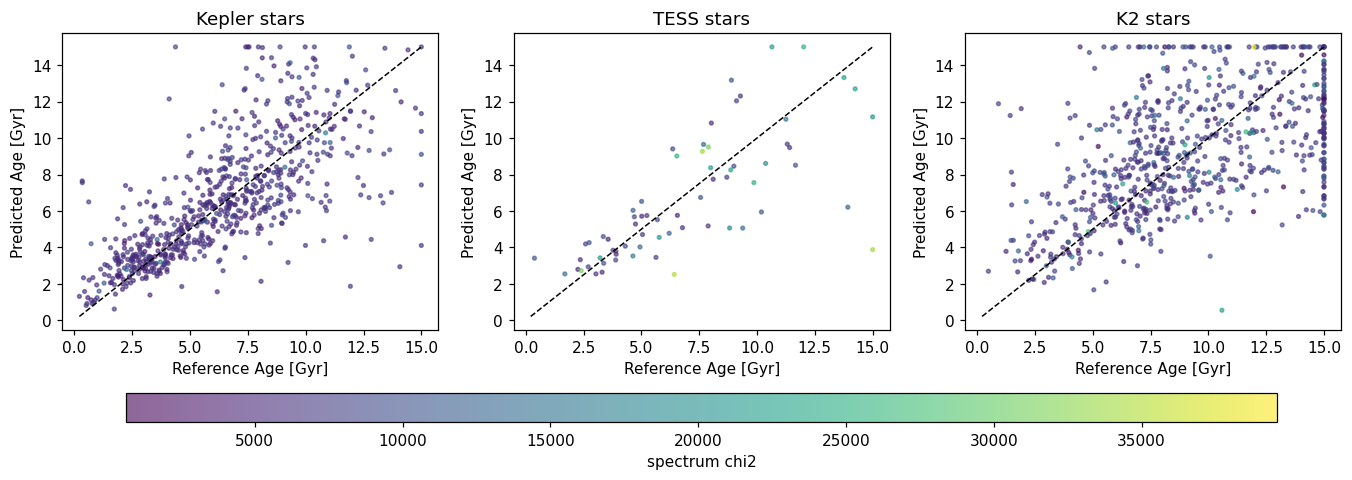

In [15]:
# Plot predicted age, not in log

# Assume: 'pred_log_age_L' is the predicted log(age) from the model in the test DataFrame,
# so predicted age in Gyr is 10**pred_log_age_L if log base 10, or np.exp(pred_log_age_L) if natural log.
# We'll plot predicted age vs. reference age.

# First, determine whether logs are base 10 or natural.
# Let's assume log10 (most common for ages in astronomy).

good_test = test[good_chi]

pred_age = np.clip(10 ** good_test['pred_log_age_L'], 0.01, 15)
ref_age = np.clip(10 ** good_test['log_age_L'], 0.01, 15)
spec_chi2 = good_test['spec_chi2']

vmin = spec_chi2.min()
vmax = spec_chi2.max()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))
scatter_objs = []
for i, source in enumerate(test['source'].unique()):
    mask = good_test['source'] == source
    sc = ax[i].scatter(
        ref_age[mask], pred_age[mask], 
        s=6, alpha=0.6, 
        c=spec_chi2[mask], 
        vmin=vmin, vmax=vmax, 
        cmap='viridis'
    )
    scatter_objs.append(sc)
    ax[i].plot([ref_age.min(), ref_age.max()], [ref_age.min(), ref_age.max()], 'k--', lw=1)
    ax[i].set_xlabel("Reference Age [Gyr]")
    ax[i].set_ylabel("Predicted Age [Gyr]")
    ax[i].set_title(f"{source} stars")
# Single colorbar for all panels, using the first scatter object
cbar = fig.colorbar(
    scatter_objs[0], 
    ax=ax,
    label='spectrum chi2', 
    orientation='horizontal', 
    pad=0.15,        # Increase padding to push colorbar under all axes
    aspect=40, 
    shrink=0.9, 
    location='bottom' # Explicitly place the colorbar below all subplots
)
plt.show()

In [16]:
good_test.columns

Index(['APOGEE_ID', 'source', 'evo_state_source', 'rgb_proba', 'EvoState',
       'snr_x', 'numax', 'raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'c_n',
       'log_age_L', 'raw_e_teff', 'raw_e_logg', 'raw_e_fe_h', 'e_mg_fe',
       'c_n_err', 'e_log_age_L', 'split', 'pred_raw_teff', 'pred_err_raw_teff',
       'pred_raw_logg', 'pred_err_raw_logg', 'pred_raw_fe_h',
       'pred_err_raw_fe_h', 'pred_mg_fe', 'pred_err_mg_fe', 'pred_c_n',
       'pred_err_c_n', 'pred_log_age_L', 'pred_err_log_age_L', 'spec_chi2',
       'spec_n_pix', 'spec_rchi2', 'resid_raw_teff', 'resid_raw_logg',
       'resid_raw_fe_h', 'resid_mg_fe', 'resid_c_n', 'resid_log_age_L'],
      dtype='str')

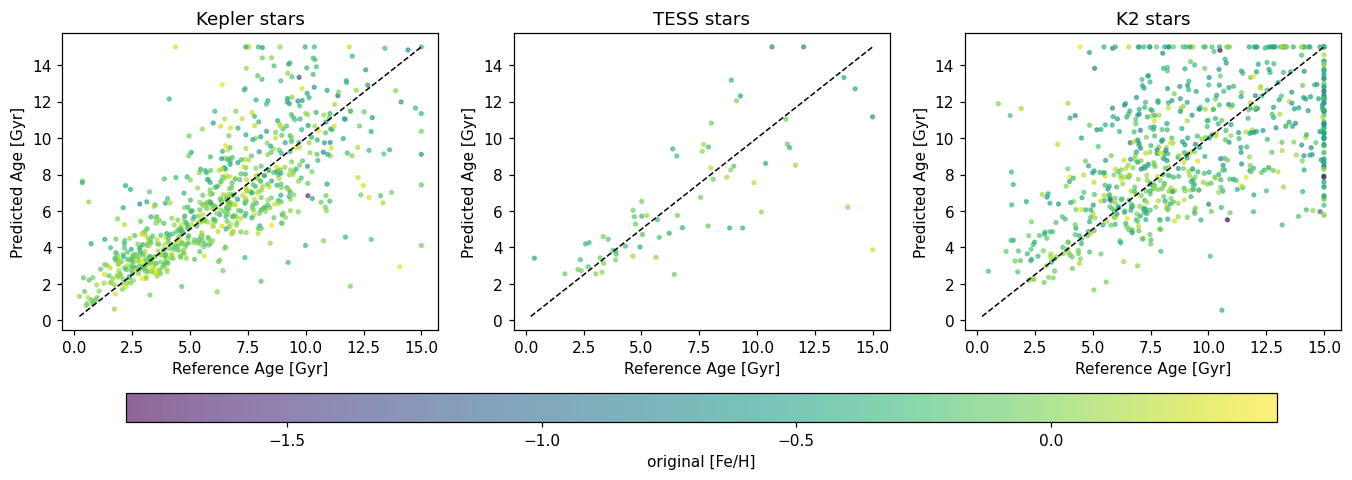

In [17]:
# Plot predicted age, not in log

# Assume: 'pred_log_age_L' is the predicted log(age) from the model in the test DataFrame,
# so predicted age in Gyr is 10**pred_log_age_L if log base 10, or np.exp(pred_log_age_L) if natural log.
# We'll plot predicted age vs. reference age.

# First, determine whether logs are base 10 or natural.
# Let's assume log10 (most common for ages in astronomy).

good_test = test[good_chi]

pred_age = np.clip(10 ** good_test['pred_log_age_L'], 0.01, 15)
ref_age = np.clip(10 ** good_test['log_age_L'], 0.01, 15)
spec_chi2 = good_test['raw_fe_h']

vmin = spec_chi2.min()
vmax = spec_chi2.max()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))
scatter_objs = []
for i, source in enumerate(test['source'].unique()):
    mask = good_test['source'] == source
    sc = ax[i].scatter(
        ref_age[mask], pred_age[mask], 
        s=6, alpha=0.6, 
        c=spec_chi2[mask], 
        vmin=vmin, vmax=vmax, 
        cmap='viridis'
    )
    scatter_objs.append(sc)
    ax[i].plot([ref_age.min(), ref_age.max()], [ref_age.min(), ref_age.max()], 'k--', lw=1)
    ax[i].set_xlabel("Reference Age [Gyr]")
    ax[i].set_ylabel("Predicted Age [Gyr]")
    ax[i].set_title(f"{source} stars")
# Single colorbar for all panels, using the first scatter object
cbar = fig.colorbar(
    scatter_objs[0], 
    ax=ax,
    label='original [Fe/H]', 
    orientation='horizontal', 
    pad=0.15,        # Increase padding to push colorbar under all axes
    aspect=40, 
    shrink=0.9, 
    location='bottom' # Explicitly place the colorbar below all subplots
)
plt.show()

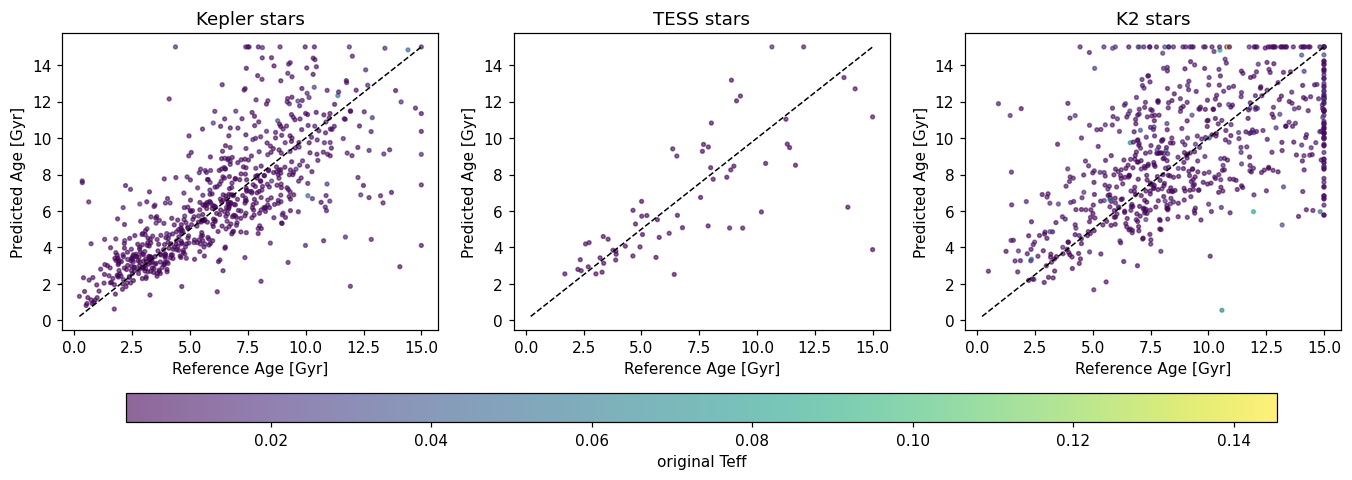

In [18]:
# Plot predicted age, not in log

# Assume: 'pred_log_age_L' is the predicted log(age) from the model in the test DataFrame,
# so predicted age in Gyr is 10**pred_log_age_L if log base 10, or np.exp(pred_log_age_L) if natural log.
# We'll plot predicted age vs. reference age.

# First, determine whether logs are base 10 or natural.
# Let's assume log10 (most common for ages in astronomy).

good_cn = test['c_n_err'] < 0.6
good_test = test[good_chi & good_cn]

pred_age = np.clip(10 ** good_test['pred_log_age_L'], 0.01, 15)
ref_age = np.clip(10 ** good_test['log_age_L'], 0.01, 15)
spec_chi2 = good_test['c_n_err']

vmin = spec_chi2.min()
vmax = spec_chi2.max()

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))
scatter_objs = []
for i, source in enumerate(test['source'].unique()):
    mask = good_test['source'] == source
    sc = ax[i].scatter(
        ref_age[mask], pred_age[mask], 
        s=6, alpha=0.6, 
        c=spec_chi2[mask], 
        vmin=vmin, vmax=vmax, 
        cmap='viridis'
    )
    scatter_objs.append(sc)
    ax[i].plot([ref_age.min(), ref_age.max()], [ref_age.min(), ref_age.max()], 'k--', lw=1)
    ax[i].set_xlabel("Reference Age [Gyr]")
    ax[i].set_ylabel("Predicted Age [Gyr]")
    ax[i].set_title(f"{source} stars")
# Single colorbar for all panels, using the first scatter object
cbar = fig.colorbar(
    scatter_objs[0], 
    ax=ax,
    label='original Teff', 
    orientation='horizontal', 
    pad=0.15,        # Increase padding to push colorbar under all axes
    aspect=40, 
    shrink=0.9, 
    location='bottom' # Explicitly place the colorbar below all subplots
)
plt.show()